### Task 1: Data Collection



Load Dataset and Selecting 10k Sentences. Using Product Reviews Data

In [6]:
import pandas as pd
import re

df = pd.read_csv("sample_data/amazon_unlocked_mobile.csv")
print(df.columns)

print(df[['reviews','rating']].head())

Index(['product_name', 'brand_name', 'price', 'rating', 'reviews',
       'review_votes'],
      dtype='object')
                                             reviews  rating
0  I feel so LUCKY to have found this used (phone...     5.0
1  nice phone, nice up grade from my pantach revu...     4.0
2                                       Very pleased     5.0
3  It works good but it goes slow sometimes but i...     4.0
4  Great phone to replace my lost phone. The only...     4.0


Clean Basic Issues - remove null and empty reviews

In [7]:
df = df.dropna(subset=['reviews'])
df = df[df['reviews'].str.strip() != ""]
print("Total reviews after cleaning:", len(df))

Total reviews after cleaning: 24430


Extract Sentences

In [8]:
import nltk
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize, word_tokenize

all_sentences = []

for review in df['reviews']:
    sentences = sent_tokenize(str(review))
    all_sentences.extend(sentences)

print("Total extracted sentences:", len(all_sentences))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Total extracted sentences: 64468


In [9]:
clean_sentences = []

for sent in all_sentences:
    if len(sent.split()) >= 3:   #sentences with >= 3 words
        clean_sentences.append(sent.strip())

print("Clean sentences count:", len(clean_sentences))

Clean sentences count: 56294


10000 Sentences Extracted

In [10]:
dataset_10k = clean_sentences[:10000]

print("Final dataset size:", len(dataset_10k))

Final dataset size: 10000


Calculate Required Statistics

In [11]:
# Number of Documents
num_documents = len(df)

# Number of Sentences
num_sentences = len(dataset_10k)

# Total Tokens
total_tokens = sum(len(word_tokenize(sent)) for sent in dataset_10k)

# Average Sentence Length
avg_sentence_length = total_tokens / num_sentences

print("Number of Documents:", num_documents)
print("Number of Sentences:", num_sentences)
print("Total Tokens:", total_tokens)
print("Average Sentence Length:", avg_sentence_length)

Number of Documents: 24430
Number of Sentences: 10000
Total Tokens: 188370
Average Sentence Length: 18.837


In [12]:
final_df = pd.DataFrame(dataset_10k, columns=["Sentence"])
final_df.to_csv("amazon_mobile_10k_sentences.csv", index=False)

### Task 2: Text Cleaning

Loading 10K Sentence Dataset

In [13]:
df = pd.read_csv("amazon_mobile_10k_sentences.csv")
sentences = df["Sentence"].tolist()

Cleaning Function

In [14]:
def clean_text(text):
  text = text.lower() #lowercasing
  text = re.sub(r'http\S+|www\S+', '', text) # remove urls
  text = re.sub(r'<.*?>', '', text) # remove HTML tags
  text = re.sub(r'[^a-z\s]', '', text) # remove special characters
  text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces

  return text

Apply Cleaning

In [15]:
cleaned_sentences = [clean_text(sent) for sent in sentences]

segmented_sentences = []

for review in cleaned_sentences:
    segmented_sentences.extend(sent_tokenize(review))

Tokenization

In [16]:
tokenized_sentences = [word_tokenize(sent) for sent in segmented_sentences]

Raw vs Processed

In [17]:
for i in range(3):
    print("RAW TEXT:")
    print(sentences[i])

    print("\nCLEANED TEXT:")
    print(cleaned_sentences[i])

    print("\nTOKENS:")
    print(tokenized_sentences[i])

    print("\n" + "-"*50)

RAW TEXT:
I feel so LUCKY to have found this used (phone to us & not used hard at all), phone on line from someone who upgraded and sold this one.

CLEANED TEXT:
i feel so lucky to have found this used phone to us not used hard at all phone on line from someone who upgraded and sold this one

TOKENS:
['i', 'feel', 'so', 'lucky', 'to', 'have', 'found', 'this', 'used', 'phone', 'to', 'us', 'not', 'used', 'hard', 'at', 'all', 'phone', 'on', 'line', 'from', 'someone', 'who', 'upgraded', 'and', 'sold', 'this', 'one']

--------------------------------------------------
RAW TEXT:
My Son liked his old one that finally fell apart after 2.5+ years and didn't want an upgrade!!

CLEANED TEXT:
my son liked his old one that finally fell apart after years and didnt want an upgrade

TOKENS:
['my', 'son', 'liked', 'his', 'old', 'one', 'that', 'finally', 'fell', 'apart', 'after', 'years', 'and', 'didnt', 'want', 'an', 'upgrade']

--------------------------------------------------
RAW TEXT:
Thank you Sel

### Task 3: Normalization

In [18]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Stopword Removal

In [19]:
stop_words = set(stopwords.words('english'))
tokens_no_stopwords = [
    [word for word in tokens if word not in stop_words]
    for tokens in tokenized_sentences
]

Stemming

In [20]:
stemmer = PorterStemmer()

stemmed_sentences = [
    [stemmer.stem(word) for word in tokens]
    for tokens in tokens_no_stopwords
]

Lemmatization

In [21]:
lemmatizer = WordNetLemmatizer()

lemmatized_sentences = [
    [lemmatizer.lemmatize(word) for word in tokens]
    for tokens in tokens_no_stopwords
]

Comparison

In [22]:
for i in range(3):
    print("Original Tokens:")
    print(tokenized_sentences[i])

    print("\nAfter Stopword Removal:")
    print(tokens_no_stopwords[i])

    print("\nAfter Stemming:")
    print(stemmed_sentences[i])

    print("\nAfter Lemmatization:")
    print(lemmatized_sentences[i])

    print("\n" + "-"*60)

Original Tokens:
['i', 'feel', 'so', 'lucky', 'to', 'have', 'found', 'this', 'used', 'phone', 'to', 'us', 'not', 'used', 'hard', 'at', 'all', 'phone', 'on', 'line', 'from', 'someone', 'who', 'upgraded', 'and', 'sold', 'this', 'one']

After Stopword Removal:
['feel', 'lucky', 'found', 'used', 'phone', 'us', 'used', 'hard', 'phone', 'line', 'someone', 'upgraded', 'sold', 'one']

After Stemming:
['feel', 'lucki', 'found', 'use', 'phone', 'us', 'use', 'hard', 'phone', 'line', 'someon', 'upgrad', 'sold', 'one']

After Lemmatization:
['feel', 'lucky', 'found', 'used', 'phone', 'u', 'used', 'hard', 'phone', 'line', 'someone', 'upgraded', 'sold', 'one']

------------------------------------------------------------
Original Tokens:
['my', 'son', 'liked', 'his', 'old', 'one', 'that', 'finally', 'fell', 'apart', 'after', 'years', 'and', 'didnt', 'want', 'an', 'upgrade']

After Stopword Removal:
['son', 'liked', 'old', 'one', 'finally', 'fell', 'apart', 'years', 'didnt', 'want', 'upgrade']

After 

### Task 4: Vocabulary Analysis

Flatten All Tokens

In [23]:
all_tokens = [word for sentence in lemmatized_sentences for word in sentence]


In [24]:
vocub = set(all_tokens)

print("Vocabulary size:", len(vocub))

Vocabulary size: 7638


Token Frequency Distribution

In [25]:
from collections import Counter

frq_dist = Counter(all_tokens)
print("Total Tokens:", len(all_tokens))

Total Tokens: 83342


Top 50 Frequent Words

In [26]:
top_50 = frq_dist.most_common(50)

for word, count in top_50:
  print(word, ":", count)

phone : 4741
good : 911
screen : 887
great : 736
work : 661
one : 650
like : 637
use : 610
price : 545
camera : 507
battery : 486
would : 478
get : 469
really : 426
dont : 403
card : 382
time : 374
love : 356
quality : 355
speaker : 348
also : 345
sim : 334
android : 328
nice : 312
well : 304
even : 298
day : 297
g : 296
apps : 295
buy : 293
back : 285
im : 278
better : 270
review : 267
feature : 264
thing : 263
call : 261
problem : 260
alcatel : 260
much : 257
need : 246
sound : 241
cant : 235
fast : 226
got : 221
make : 221
using : 218
ive : 217
bought : 217
take : 216


Rare Word Statistics

In [30]:
rare_words = [word for word, count in frq_dist.items() if count==1]
rare_count = len(rare_words)

print("Total Rare Words:", rare_count)
print("Percentage of Rare Words:", (rare_count / len(vocub)) * 100)

Total Rare Words: 3803
Percentage of Rare Words: 49.79052107881645


Zipf’s Law Curve

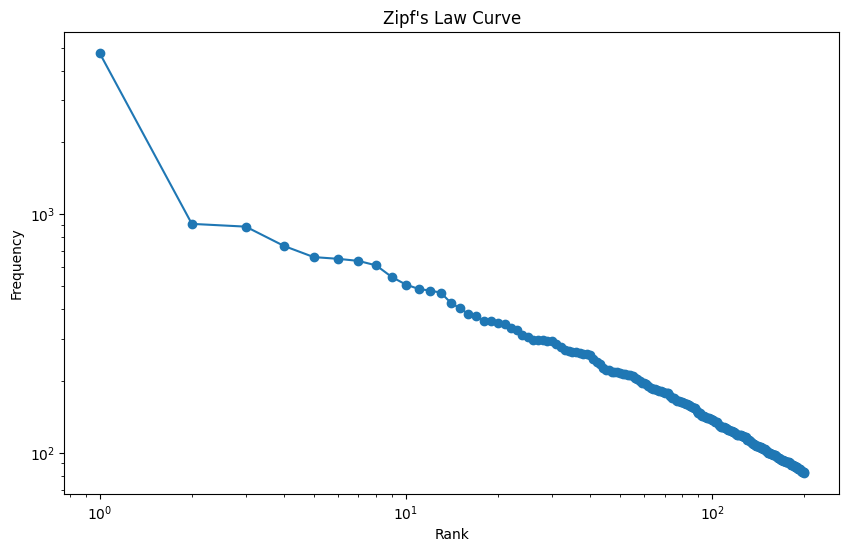

In [31]:
import matplotlib.pyplot as plt

sorted_frq = sorted(frq_dist.values(), reverse=True)

ranks = range(1, len(sorted_frq)+1)

plt.figure(figsize=(10, 6))
plt.plot(ranks[:200], sorted_frq[:200], marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title("Zipf's Law Curve")
plt.show()

Word Frequency Histogram

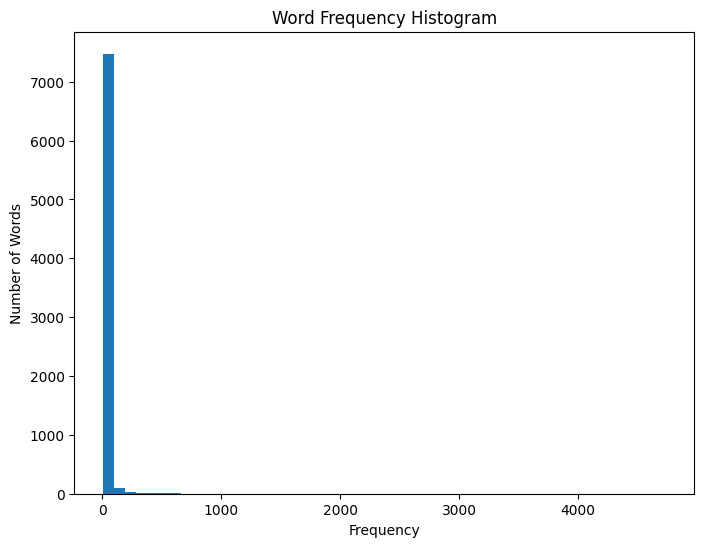

In [32]:
plt.figure(figsize=(8, 6))
plt.hist(sorted_frq, bins=50)
plt.xlabel('Frequency')
plt.ylabel('Number of Words')
plt.title('Word Frequency Histogram')
plt.show()

### Task 5: N-gram Analysis

In [34]:
from nltk.util import ngrams
from collections import Counter

Prepare Token List

In [35]:
all_tokens = [word for sentence in lemmatized_sentences for word in sentence]

Unigrams

In [36]:
unigram_frq = Counter(all_tokens)

print("Top 20 Unigrams:")
print(unigram_frq.most_common(20))

Top 20 Unigrams:
[('phone', 4741), ('good', 911), ('screen', 887), ('great', 736), ('work', 661), ('one', 650), ('like', 637), ('use', 610), ('price', 545), ('camera', 507), ('battery', 486), ('would', 478), ('get', 469), ('really', 426), ('dont', 403), ('card', 382), ('time', 374), ('love', 356), ('quality', 355), ('speaker', 348)]


Bigrams

In [37]:
bigrams = list(ngrams(all_tokens, 2))
bigram_frq = Counter(bigrams)

print("Top 20 Bigrams:")
print(bigram_frq.most_common(20))

Top 20 Bigrams:
[(('sim', 'card'), 203), (('battery', 'life'), 169), (('great', 'phone'), 139), (('phone', 'work'), 107), (('sd', 'card'), 103), (('phone', 'price'), 93), (('cell', 'phone'), 88), (('screen', 'protector'), 88), (('love', 'phone'), 85), (('phone', 'good'), 85), (('phone', 'great'), 82), (('good', 'phone'), 77), (('front', 'facing'), 77), (('moto', 'g'), 73), (('android', 'phone'), 68), (('use', 'phone'), 67), (('phone', 'would'), 66), (('work', 'well'), 66), (('phone', 'phone'), 65), (('phone', 'call'), 63)]


Trigrams

In [39]:
trigrams = list(ngrams(all_tokens, 3))
trigram_frq = Counter(trigrams)

print("Top 20 Trigrams:")
print(trigram_frq.most_common(20))

Top 20 Trigrams:
[(('front', 'facing', 'speaker'), 50), (('double', 'tap', 'wake'), 23), (('great', 'phone', 'price'), 22), (('micro', 'sd', 'card'), 19), (('sim', 'card', 'phone'), 18), (('exchange', 'honest', 'unbiased'), 18), (('honest', 'unbiased', 'review'), 18), (('good', 'battery', 'life'), 17), (('worst', 'phone', 'ever'), 17), (('sim', 'card', 'slot'), 16), (('unlocked', 'dual', 'sim'), 16), (('case', 'screen', 'protector'), 16), (('phone', 'great', 'price'), 15), (('really', 'like', 'phone'), 15), (('discounted', 'price', 'exchange'), 15), (('price', 'exchange', 'honest'), 15), (('phone', 'work', 'well'), 14), (('dual', 'sim', 'card'), 14), (('front', 'facing', 'camera'), 14), (('high', 'end', 'phone'), 14)]


### Task 6: Train / Validation / Test Split

Load Final Dataset

In [40]:
import pandas as pd
df = pd.read_csv("amazon_mobile_10k_sentences.csv")
print("Total Samples:", len(df))

Total Samples: 10000


Import Train-Test Split

In [41]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

print("Train Size:", len(train_df))
print("Temp Size:", len(temp_df))

Train Size: 8000
Temp Size: 2000


Split Temp into Validation & Test (10% + 10%)

In [44]:
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

print("Validation Size:", len(val_df))
print("Test Size:", len(test_df))

Validation Size: 1000
Test Size: 1000


Save Files

In [45]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)